# Script for reading data from HDOS device
The script reads data with format v2.

## Importing necessary Python modules

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import multiprocessing
import platform
from tqdm import tqdm
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.io import loadmat, savemat
from scipy import interpolate
from glob import glob

from myFunctions_TRS import getFitResult2_TRS, getFitResult1_TRS, Reflectance_Contini
from myFunctions_DCS import getFitResult2_DCS


In [3]:
from HDOS2_DATAREAD_v2 import HDOS2_FOLDERREAD_DCS_RAW_v2, HDOS2_FOLDERREAD_DCS_FIT_v2
from HDOS2_DATAREAD_v2 import HDOS2_FOLDERREAD_TRS_RAW_v2, HDOS2_FOLDERREAD_TRS_FIT_v2
from HDOS2_DATAREAD_v2 import HDOS2_FOLDERREAD_SENSOR_v2, HDOS2_FOLDERREAD_PPG_v2

dataFolder = "./tests/HDOS-icfo_Mindlab_4_VASC_ENDO_260715152934/"
IRFfolder = "./tests/HDOS-icfo_Mindlab_4_VASC_ENDO_260715152934/measurement_info/"

DataFolder=dataFolder


## Reading sensor data

In [4]:
system_time_sensor, corr_time_sensor, trs_time_sensor, sen_touch, sen_accel_x, sen_accel_y, sen_accel_z, sen_accel_alert, \
sen_load, sen_load_alert, sen_light, sen_TRS_laser, sen_DCS_laser, sen_TRS_quality, sen_DCS_quality, \
sen_key_pressed, sen_bat1_charge, sen_bat2_charge, sen_bat3_charge, sen_bat4_charge, sen_safety_board_out_enable, \
sen_reset_required_10s, sen_spo2, sen_pulse, sen_oxymeter_quality, sen_oxymeter_info, sen_cuff_pressure, \
mark_inflate, mark_deflate, mark_general1, mark_general2, mark_quality_phase, serial_number_io, firmware_version_stm \
= HDOS2_FOLDERREAD_SENSOR_v2(dataFolder)

#sen_system_time=system_time_sensor-system_time_sensor[0]
bb=np.squeeze(np.where(mark_quality_phase == 0))
sen_system_time=system_time_sensor-system_time_sensor[bb[0]]

print(f"serial_number_io: {hex(serial_number_io[0])}\nfirmware_version_stm: {hex(firmware_version_stm[0])}")

100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 62.41it/s]


serial_number_io: 0x14
firmware_version_stm: 0x19b0


In [5]:
mark_quality_phase.shape

(15909,)

## Reading raw DCS data

In [6]:
system_time_raw_dcs, dcs_time, dcs_frame_raw, no_of_channels, \
dcs_corr_1, dcs_int_1, dcs_corr_2, dcs_int_2, \
dcs_corr_3, dcs_int_3, dcs_corr_4, dcs_int_4 \
= HDOS2_FOLDERREAD_DCS_RAW_v2(dataFolder)

100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [00:02<00:00, 11.37it/s]


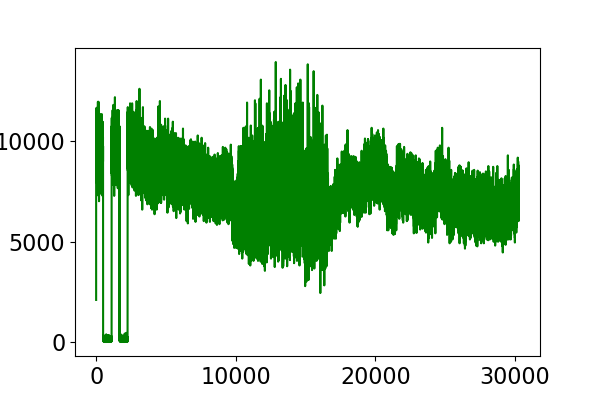

In [28]:

plt.figure()
plt.plot(dcs_int_1, '-g')

## Reading fitted DCS data

In [7]:
system_time_fit_dcs, dcs_frame_fit, corr_bfi, \
corr_beta, corr_tau_c, corr_tau_tail, corr_r2 \
= HDOS2_FOLDERREAD_DCS_FIT_v2(dataFolder)

bb=np.squeeze(np.where(mark_quality_phase == 0))
differences=np.abs(system_time_fit_dcs-system_time_sensor[bb[0]])
closest_index_qf = differences.argmin()

dcs_system_time = (system_time_fit_dcs - system_time_fit_dcs[closest_index_qf])/1000


100%|█████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 424.44it/s]


## Reading raw TD-NIRS data

In [8]:
system_time_raw_trs, trs_time, trs_frame, trs_dtof_685, trs_count_rate_685, \
    trs_dtof_828, trs_count_rate_828 = HDOS2_FOLDERREAD_TRS_RAW_v2(dataFolder)

100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [00:01<00:00, 17.75it/s]


## Reading fitted TD-NIRS data

In [9]:
system_time_fit_trs, trs_frame_fit, trs_mua_685, trs_mus_685, trs_peak_pos_685, trs_chi2_685, \
trs_fwhm_685, trs_mua_828, trs_mus_828, trs_peak_pos_828, trs_chi2_828, trs_fwhm_828, trs_mua_785, \
trs_mus_785, trs_hbo, trs_hbr, trs_hbt, trs_sto2, trs_toe, trs_mro2  \
= HDOS2_FOLDERREAD_TRS_FIT_v2(dataFolder)

bb=np.squeeze(np.where(mark_quality_phase == 0))
differences=np.abs(system_time_fit_trs-system_time_sensor[bb[0]])
closest_index_qf = differences.argmin()

trs_system_time = (system_time_fit_trs - system_time_fit_trs[closest_index_qf])/1000


100%|█████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 566.90it/s]


## Reading PPG data

In [10]:
system_time_ppg, corr_time_ppg, trs_time_ppg, value_ppg  = HDOS2_FOLDERREAD_PPG_v2(dataFolder)

100%|█████████████████████████████████████████████████████████████████████████████████| 31/31 [00:00<00:00, 100.96it/s]


# 2. Analyze, plot and save sensor data
#### The sensor board records several signals:
- Pressurre of the cuff (not shown here)
- Marks (general marks, quality phase marks, cuff occlusion marks)
- Arterial blood oxygen saturation (pulseoximeter SpO2)
- Heart-beat
- PPG (not shown here)
- Accelerometer (not shown)
- Load and touch sensors (not shown)

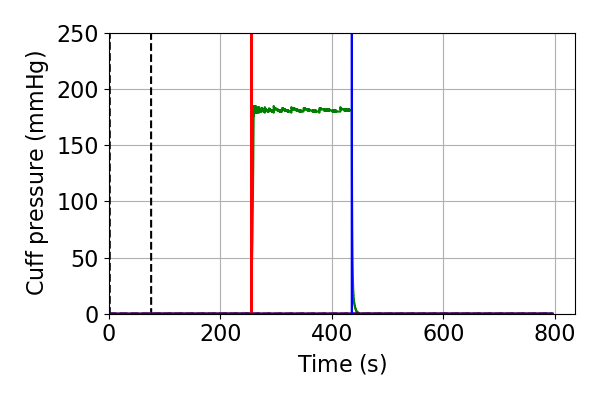

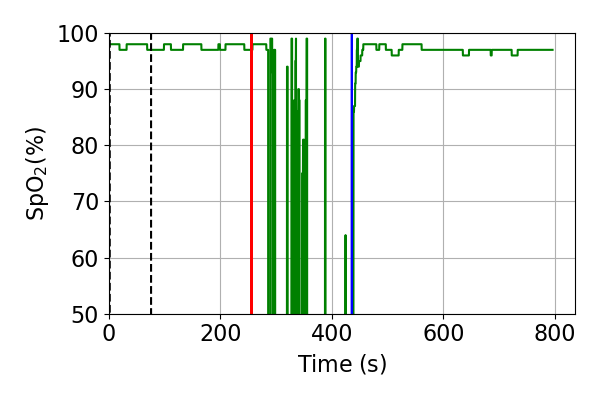

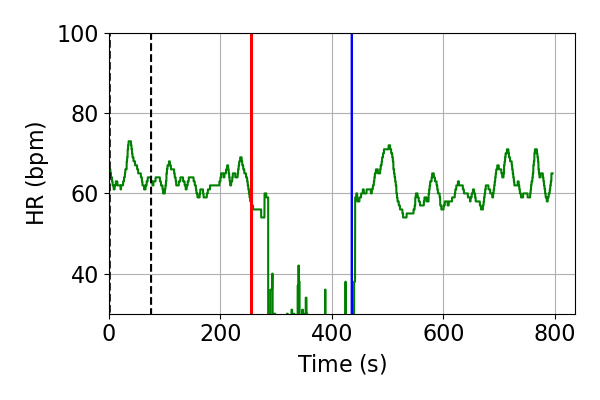

In [11]:
%matplotlib widget
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 16

plt.figure()
plt.plot(sen_system_time/1000, sen_cuff_pressure, '-g')
plt.plot(sen_system_time/1000, 500*mark_general1, '--k', label = "gen1")
plt.plot(sen_system_time/1000, 500*mark_general2, '--k', label = "gen2")
plt.plot(sen_system_time/1000, 500*mark_quality_phase, '--k', label = "QP")
plt.plot(sen_system_time/1000, 500*mark_inflate, '-r', label = "inflate")
plt.plot(sen_system_time/1000, 500*mark_deflate, '-b', label = "deflate")
plt.xlabel('$\\rm Time \;(s)$')
plt.ylabel('$\\rm Cuff \; pressure \;(mmHg)$')
plt.ylim(0,250)
plt.xlim(0,)
plt.grid()
plt.tight_layout()
plt.savefig(f"./CuffPressure_{DataFolder.split(sep = '/')[-2]}.png")  
plt.show()



plt.figure()
plt.plot(sen_system_time/1000, sen_spo2, '-g')
plt.plot(sen_system_time/1000, 500*mark_general1, '--k', label = "gen1")
plt.plot(sen_system_time/1000, 500*mark_general2, '--k', label = "gen2")
plt.plot(sen_system_time/1000, 500*mark_quality_phase, '--k', label = "QP")
plt.plot(sen_system_time/1000, 500*mark_inflate, '-r', label = "inflate")
plt.plot(sen_system_time/1000, 500*mark_deflate, '-b', label = "deflate")

plt.xlabel('$\\rm Time \;(s)$')
plt.ylabel('$\\rm SpO_{2} (\%)$')
plt.ylim(50,100)
plt.xlim(0,)
plt.grid()
plt.tight_layout()
plt.savefig(f"./SpO2_{DataFolder.split(sep = '/')[-2]}.png")   
plt.show()



plt.figure()
plt.plot(sen_system_time/1000, sen_pulse, '-g')
plt.plot(sen_system_time/1000, 500*mark_general1, '--k', label = "gen1")
plt.plot(sen_system_time/1000, 500*mark_general2, '--k', label = "gen2")
plt.plot(sen_system_time/1000, 500*mark_quality_phase, '--k', label = "QP")
plt.plot(sen_system_time/1000, 500*mark_inflate, '-r', label = "inflate")
plt.plot(sen_system_time/1000, 500*mark_deflate, '-b', label = "deflate")

plt.xlabel('$\\rm Time \;(s)$')
plt.ylabel('$\\rm HR \; (bpm)$')
plt.ylim(30,100)
plt.xlim(0,)
plt.grid()
plt.tight_layout()
plt.savefig(f"./HR_{DataFolder.split(sep = '/')[-2]}.png")   
plt.show()

### Plot saturation vs time

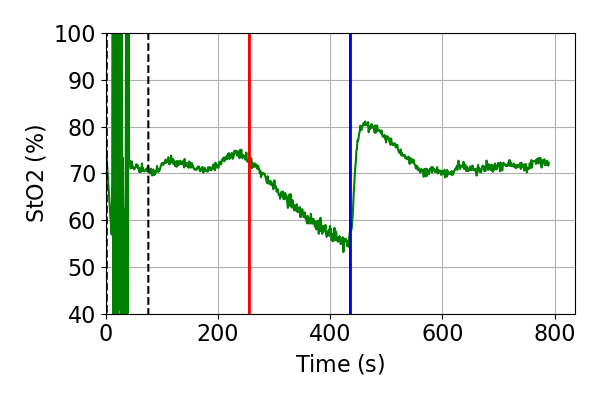

In [12]:

%matplotlib widget
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 16

plt.figure()
plt.plot(trs_system_time, trs_sto2, '-g')
plt.plot(sen_system_time/1000, 500*mark_general1, '--k', label = "gen1")
plt.plot(sen_system_time/1000, 500*mark_general2, '--k', label = "gen2")
plt.plot(sen_system_time/1000, 500*mark_quality_phase, '--k', label = "QP")
plt.plot(sen_system_time/1000, 500*mark_inflate, '-r', label = "inflate")
plt.plot(sen_system_time/1000, 500*mark_deflate, '-b', label = "deflate")
plt.xlabel('$\\rm Time \;(s)$')
plt.ylabel('$\\rm StO2 \;(\%)$')
plt.ylim(40,100)
plt.xlim(0,)
plt.grid()
plt.tight_layout()
plt.savefig(f"./CuffPressure_{DataFolder.split(sep = '/')[-2]}.png")  
plt.show()

### Define baseline, deoxygenation and reoxygenation intervals, and calculate VOT main parameters for saturation

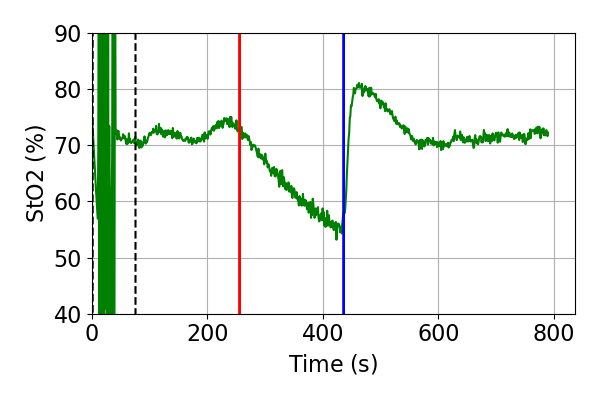

Baseline StO2 (%): 71.97258380227082
Slope DeOx (%/min): -7.635766066991501
Slope ReOx (%/s): 1.7779730255527972
Recovery Baseline StO2 (%): 70.65713529225899
Area under the curve (% min) 11.124858563950557


In [24]:
import numpy as np
from scipy import integrate

%matplotlib widget
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 16

plt.figure()
plt.plot(trs_system_time, trs_sto2, '-g')
plt.plot(sen_system_time/1000, 500*mark_general1, '--k', label = "gen1")
plt.plot(sen_system_time/1000, 500*mark_general2, '--k', label = "gen2")
plt.plot(sen_system_time/1000, 500*mark_quality_phase, '--k', label = "QP")
plt.plot(sen_system_time/1000, 500*mark_inflate, '-r', label = "inflate")
plt.plot(sen_system_time/1000, 500*mark_deflate, '-b', label = "deflate")
plt.xlabel('$\\rm Time \;(s)$')
plt.ylabel('$\\rm StO2 \;(\%)$')
plt.ylim(40,90)
plt.xlim(0,)
plt.grid()
plt.tight_layout()
plt.show()

#############################

baseline_start_time = 110 # first baseline (pre vot)
baseline_end_time = 229

baseline_start = np.abs(trs_system_time - baseline_start_time).argmin()
baseline_end = np.abs(trs_system_time - baseline_end_time).argmin()

mean_bsl_sto = np.mean(trs_sto2[baseline_start:baseline_end])
sto2_bsl = mean_bsl_sto;
print("Baseline StO2 (%):", mean_bsl_sto)
plt.fill_between(trs_system_time, np.min(trs_sto2[baseline_start:baseline_end]), np.max(trs_sto2[baseline_start:baseline_end]), where=(trs_system_time >= baseline_start_time) & (trs_system_time <= baseline_end_time), color='red', alpha=0.5)

#############################
 
slope_start_time = 252  # start of occlusion
slope_end_time = slope_start_time + 60 # we normally consider first minute of occlusion for the descending slope

slope_start = np.abs(trs_system_time - slope_start_time).argmin()
slope_end = np.abs(trs_system_time - slope_end_time).argmin()

slope, intercept = np.polyfit(trs_system_time[slope_start:slope_end], trs_sto2[slope_start:slope_end], 1)
deox = slope * 60 #in %/min
print("Slope DeOx (%/min):", slope * 60)

#plt.fill_between(trs_system_time, np.min(trs_sto2[slope_start:slope_end]), np.max(trs_sto2[slope_start:slope_end]), where=(trs_system_time >= slope_start_time) & (trs_system_time <= slope_end_time), color='red', alpha=0.5)
y_line = slope * trs_system_time[slope_start:slope_end] + intercept
plt.plot(trs_system_time[slope_start:slope_end], y_line, color="yellow", linestyle="--", label=f"Fitted line: y = {slope:.2f}x + {intercept:.2f}")

############################
slope_start_time = 437 # start of cuff release
slope_end_time = 447 # 

slope_start = np.abs(trs_system_time - slope_start_time).argmin()
slope_end = np.abs(trs_system_time - slope_end_time).argmin()

slope, intercept = np.polyfit(trs_system_time[slope_start:slope_end], trs_sto2[slope_start:slope_end], 1)
reox = slope
print("Slope ReOx (%/s):", slope)

#plt.fill_between(trs_system_time, np.min(trs_sto2[slope_start:slope_end]), np.max(trs_sto2[slope_start:slope_end]), where=(trs_system_time >= slope_start_time) & (trs_system_time <= slope_end_time), color='red', alpha=0.5)
y_line = slope * trs_system_time[slope_start:slope_end] + intercept
plt.plot(trs_system_time[slope_start:slope_end], y_line, color="yellow", linestyle="--", label=f"Fitted line: y = {slope:.2f}x + {intercept:.2f}")

###########################
baseline_start_time = 584 # second baseline (recovery)
baseline_end_time = 649

baseline_start = np.abs(trs_system_time - baseline_start_time).argmin()
baseline_end = np.abs(trs_system_time - baseline_end_time).argmin()

mean_bsl_sto = np.mean(trs_sto2[baseline_start:baseline_end])
sto2_rec = mean_bsl_sto;
print("Recovery Baseline StO2 (%):", mean_bsl_sto)
plt.fill_between(trs_system_time, np.min(trs_sto2[baseline_start:baseline_end]), np.max(trs_sto2[baseline_start:baseline_end]), where=(trs_system_time >= baseline_start_time) & (trs_system_time <= baseline_end_time), color='red', alpha=0.5)

###########################
AUC_start_time = 446 # area start
AUC_end_time = 566

AUC_start = np.abs(trs_system_time - AUC_start_time).argmin()
AUC_end = np.abs(trs_system_time - AUC_end_time).argmin()

area_trapz = integrate.trapezoid(trs_sto2[AUC_start:AUC_end] - mean_bsl_sto, trs_system_time[AUC_start:AUC_end])
AUC_sto2 = area_trapz / 60 #in %*min
print("Area under the curve (% min)", area_trapz / 60)

plt.fill_between(trs_system_time, trs_sto2, mean_bsl_sto, where=(trs_system_time >= AUC_start_time) & (trs_system_time <= AUC_end_time), color='red', alpha=0.5);



### Plot blood flow vs time

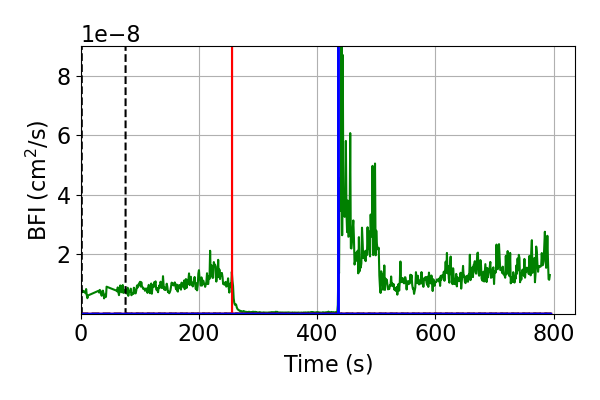

In [25]:
%matplotlib widget
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 16

plt.figure()
plt.plot(dcs_system_time, corr_bfi, '-g')
plt.plot(sen_system_time/1000, 500*mark_general1, '--k', label = "gen1")
plt.plot(sen_system_time/1000, 500*mark_general2, '--k', label = "gen2")
plt.plot(sen_system_time/1000, 500*mark_quality_phase, '--k', label = "QP")
plt.plot(sen_system_time/1000, 500*mark_inflate, '-r', label = "inflate")
plt.plot(sen_system_time/1000, 500*mark_deflate, '-b', label = "deflate")
plt.xlabel('$\\rm Time \;(s)$')
plt.ylabel('$\\rm BFI \; (cm^{2}/s)$')
plt.ylim(1e-11, 9e-8)
plt.xlim(0,)
plt.grid()
plt.tight_layout()
plt.savefig(f"./CuffPressure_{DataFolder.split(sep = '/')[-2]}.png")  
plt.show()

### Define baseline, deoxygenation and reoxygenation intervals, and calculate VOT main parameters for blood flow

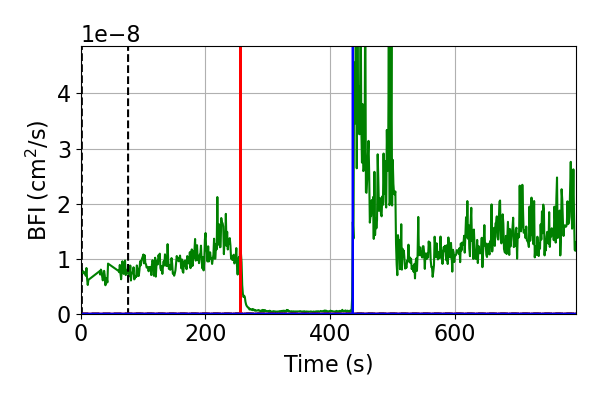

Baseline BFI  (cm^{2}): 1.1013453634436793e-08
Recovery baseline BFI  (cm^{2}): 1.171921325284287e-08
Area under the curve (cm2/s min) 6.637293208347984e-05


In [27]:
import numpy as np
from scipy import integrate
%matplotlib widget
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 16

plt.figure()
plt.plot(dcs_system_time, corr_bfi, '-g')
plt.plot(sen_system_time/1000, 500*mark_general1, '--k', label = "gen1")
plt.plot(sen_system_time/1000, 500*mark_general2, '--k', label = "gen2")
plt.plot(sen_system_time/1000, 500*mark_quality_phase, '--k', label = "QP")
plt.plot(sen_system_time/1000, 500*mark_inflate, '-r', label = "inflate")
plt.plot(sen_system_time/1000, 500*mark_deflate, '-b', label = "deflate")
plt.xlabel('$\\rm Time \;(s)$')
plt.ylabel('$\\rm BFI \; (cm^{2}/s)$')

# Use the 99th percentile instead of the true max, so a single spike/artifact
# doesn't compress the rest of the trace. Adjust the percentile if needed.
y_upper = np.nanpercentile(corr_bfi, 99) * 1.2
plt.ylim(0, y_upper)
plt.xlim(0, np.nanmax(dcs_system_time))

plt.grid()
plt.tight_layout()
plt.savefig(f"./CuffPressure_{DataFolder.split(sep = '/')[-2]}.png")
plt.show()

baseline_start_time = 150
baseline_end_time = 235
baseline_start = np.abs(dcs_system_time - baseline_start_time).argmin()
baseline_end = np.abs(dcs_system_time - baseline_end_time).argmin()
mean_bsl_bfi = np.mean(corr_bfi[baseline_start:baseline_end])
bfi_bsl = mean_bsl_bfi
print("Baseline BFI  (cm^{2}):", mean_bsl_bfi)
plt.fill_between(dcs_system_time, np.min(corr_bfi[baseline_start:baseline_end]), np.max(corr_bfi[baseline_start:baseline_end]),
                  where=(dcs_system_time >= baseline_start_time) & (dcs_system_time <= baseline_end_time), color='red', alpha=0.5)

# recovery baseline
baseline_start_time = 560
baseline_end_time = 640
baseline_start = np.abs(dcs_system_time - baseline_start_time).argmin()
baseline_end = np.abs(dcs_system_time - baseline_end_time).argmin()
mean_bsl_bfi = np.mean(corr_bfi[baseline_start:baseline_end])
bfi_rec = mean_bsl_bfi
print("Recovery baseline BFI  (cm^{2}):", mean_bsl_bfi)
plt.fill_between(dcs_system_time, np.min(corr_bfi[baseline_start:baseline_end]), np.max(corr_bfi[baseline_start:baseline_end]),
                  where=(dcs_system_time >= baseline_start_time) & (dcs_system_time <= baseline_end_time), color='red', alpha=0.5)

AUC_start_time = 434
AUC_end_time = 570
AUC_start = np.abs(dcs_system_time - AUC_start_time).argmin()
AUC_end = np.abs(dcs_system_time - AUC_end_time).argmin()
area_trapz = integrate.trapezoid(corr_bfi[AUC_start:AUC_end] - mean_bsl_bfi, dcs_system_time[AUC_start:AUC_end])
AUC_bfi = area_trapz * 60
print("Area under the curve (cm2/s min)", area_trapz * 60)
plt.fill_between(dcs_system_time, corr_bfi, mean_bsl_bfi,
                  where=(dcs_system_time >= AUC_start_time) & (dcs_system_time <= AUC_end_time), color='red', alpha=0.5)

### Save sensor data to a CSV file.

In [33]:
Labels = ['Time(s)', 'CuffPressure(mmHg)', 'HR(bpm)', 'SpO2(%)', 'Gen1Marks', \
          'Gen1Marks', 'QPMarks', 'InflationMarks', 'DeflationMarks']

dataframe = pd.DataFrame(np.array([sen_system_time, sen_cuff_pressure, sen_pulse, sen_spo2, mark_general1, \
                                   mark_general2, mark_quality_phase, mark_inflate, mark_deflate]).T) 
dataframe.columns = Labels
dataframe.to_csv(f"sen_{DataFolder.split(sep = '/')[-2]}.csv", header=True, index = False)

#### Subject number, sex

In [30]:
subject = 1
sex = 1
arm_fat = 0.8 # thickness of fat layer in cm

#### Create table with VOT parameters and save data

In [31]:
c=np.array([subject, sex, arm_fat, sto2_bsl, deox, reox,sto2_rec, 
                                   AUC_sto2, bfi_bsl, bfi_rec, AUC_bfi])
dataframe = pd.DataFrame(c.T)
dataframe = np.transpose(dataframe)


Labels = ['Subject', 'Sex',  'Arm fat thick.', 'StO2 bas(%)', 'DeOx (%/min)', 
          'ReOx(%/s)', 'StO2 rec(%)' ,'AUC StO2 (%min)',  
          'BF bas.(cm2/s)', 'BF rec(cm2/s)', 'AUC BF(cm2/s min)']

#dataframe = pd.DataFrame(np.array([subject, breath_hold_dur, spo2_bas, spo2_peak, spo2delta, spo2delta_index, sto2_bas, sto2_peak, sto2delta,sto2delta_index, 
                                   #hbt_bas, hbt_peak, hbtdelta,hbtdelta_index, bf_bas, bf_peak, bfdelta,bfdelta_index]).T) 

dataframe = pd.DataFrame(np.array([subject, sex, arm_fat, sto2_bsl, deox, reox,sto2_rec, 
                                   AUC_sto2, bfi_bsl, bfi_rec, AUC_bfi]))
dataframe = np.transpose(dataframe)

dataframe.columns = Labels
dataframe.to_csv(f"RESULTS_VOT_{DataFolder.split(sep = '/')[-2]}.csv", header=True, index = False)
dataframe

,Subject,Sex,Arm fat thick.,StO2 bas(%),DeOx (%/min),ReOx(%/s),StO2 rec(%),AUC StO2 (%min),BF bas.(cm2/s),BF rec(cm2/s),AUC BF(cm2/s min)
0,1.0,1.0,0.8,71.972584,-7.635766,1.777973,70.657135,11.124859,1.101345e-08,1.171921e-08,0.000066
